In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/devanarayancs/latencydataset/latency_data_v2.csv


In [2]:
!pip install -U pip setuptools wheel
!pip install autogluon

In [3]:
!pip install -U pyarrow autogluon

  Using cached pyarrow-25.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)


In [4]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [5]:
df = pd.read_csv("/kaggle/input/datasets/devanarayancs/latencydataset/latency_data_v2.csv")
df.head()

,timestamp,request_count,active_users,cpu_usage,memory_usage,db_query_time_ms,p50_latency_ms,p95_latency_ms,p99_latency_ms,error_rate,...,memory_change_5m,db_change_5m,cpu_2h_mean,cpu_2h_std,memory_2h_mean,memory_2h_std,cpu_percentile,memory_percentile,cpu_memory_stress,cpu_load_stress
0,2026-04-01 00:00:00,144,66,32.68,40.78,15.64,75.98,132.57,187.75,0.00106,...,-1.087,-0.138,40.71,8.71,47.5,7.38,25.3,24.8,0.1333,0.0589
1,2026-04-01 00:05:00,131,60,33.79,40.51,15.58,76.70,135.97,168.02,0.00092,...,0.554,0.019,40.71,8.71,47.5,7.38,30.9,22.9,0.1369,0.0553
2,2026-04-01 00:10:00,138,63,34.07,41.89,15.68,80.48,134.42,178.29,0.00152,...,1.553,-0.019,40.71,8.71,47.5,7.38,32.2,31.7,0.1427,0.0587
3,2026-04-01 00:15:00,141,65,32.19,43.62,15.55,74.53,131.01,160.72,0.00101,...,-0.605,-0.442,40.71,8.71,47.5,7.38,22.6,38.2,0.1404,0.0569
4,2026-04-01 00:20:00,126,59,32.93,40.68,14.80,74.54,121.27,168.82,0.00182,...,-0.753,-0.287,40.71,8.71,47.5,7.38,26.7,24.1,0.1340,0.0520


In [6]:
df["item_id"] = "server_1"

# 3. Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 4. Convert to AutoGluon TimeSeriesDataFrame
train_data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp"
)

train_data.head()

request_count  active_users  cpu_usage  \
item_id  timestamp                                                     
server_1 2026-04-01 00:00:00            144            66      32.68   
         2026-04-01 00:05:00            131            60      33.79   
         2026-04-01 00:10:00            138            63      34.07   
         2026-04-01 00:15:00            141            65      32.19   
         2026-04-01 00:20:00            126            59      32.93   

                              memory_usage  db_query_time_ms  p50_latency_ms  \
item_id  timestamp                                                             
server_1 2026-04-01 00:00:00         40.78             15.64           75.98   
         2026-04-01 00:05:00         40.51             15.58           76.70   
         2026-04-01 00:10:00         41.89             15.68           80.48   
         2026-04-01 00:15:00         43.62             15.55           74.53   
         2026-04-01 00:20:00         40.68             14.80           74.54   

                              p95_latency_ms  p99_latency_ms  error_rate  \
item_id  timestamp                                                         
server_1 2026-04-01 00:00:00          132.57          187.75     0.00106   
         2026-04-01 00:05:00          135.97          168.02     0.00092   
         2026-04-01 00:10:00          134.42          178.29     0.00152   
         2026-04-01 00:15:00          131.01          160.72     0.00101   
         2026-04-01 00:20:00          121.27          168.82     0.00182   

                              cpu_change_5m  memory_change_5m  db_change_5m  \
item_id  timestamp                                                            
server_1 2026-04-01 00:00:00          1.519            -1.087        -0.138   
         2026-04-01 00:05:00          0.696             0.554         0.019   
         2026-04-01 00:10:00         -0.797             1.553        -0.019   
         2026-04-01 00:15:00         -0.571            -0.605        -0.442   
         2026-04-01 00:20:00          1.121            -0.753        -0.287   

                              cpu_2h_mean  cpu_2h_std  memory_2h_mean  \
item_id  timestamp                                                      
server_1 2026-04-01 00:00:00        40.71        8.71            47.5   
         2026-04-01 00:05:00        40.71        8.71            47.5   
         2026-04-01 00:10:00        40.71        8.71            47.5   
         2026-04-01 00:15:00        40.71        8.71            47.5   
         2026-04-01 00:20:00        40.71        8.71            47.5   

                              memory_2h_std  cpu_percentile  \
item_id  timestamp                                            
server_1 2026-04-01 00:00:00           7.38            25.3   
         2026-04-01 00:05:00           7.38            30.9   
         2026-04-01 00:10:00           7.38            32.2   
         2026-04-01 00:15:00           7.38            22.6   
         2026-04-01 00:20:00           7.38            26.7   

                              memory_percentile  cpu_memory_stress  \
item_id  timestamp                                                   
server_1 2026-04-01 00:00:00               24.8             0.1333   
         2026-04-01 00:05:00               22.9             0.1369   
         2026-04-01 00:10:00               31.7             0.1427   
         2026-04-01 00:15:00               38.2             0.1404   
         2026-04-01 00:20:00               24.1             0.1340   

                              cpu_load_stress  
item_id  timestamp                             
server_1 2026-04-01 00:00:00           0.0589  
         2026-04-01 00:05:00           0.0553  
         2026-04-01 00:10:00           0.0587  
         2026-04-01 00:15:00           0.0569  
         2026-04-01 00:20:00           0.0520

In [7]:
# Choose what you want to predict (e.g., 'p95_latency_ms' or 'cpu_usage')
TARGET_COLUMN = "p95_latency_ms"

# Initialize predictor
predictor = TimeSeriesPredictor(
    prediction_length=12,  # Predict the next 1 hour (12 five-minute steps)
    target=TARGET_COLUMN,
    eval_metric="MASE",
    path="autogluon-latency-model"
)

# Train the models
predictor.fit(
    train_data,
    presets="medium_quality",
    time_limit=300  # 5 minutes training limit
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/kaggle/working/autogluon-latency-model'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat May 30 15:40:53 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.12 GB, Allocated: 0.00 GB, Total: 29.12 GB
GPU Count:          2
Memory Avail:       29.79 GB / 31.35 GB (95.0%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 12,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows

config.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/112M [00:00<?, ?B/s]

	-0.2071       = Validation score (-MASE)
	18.49   s     = Training runtime
	0.70    s     = Validation (prediction) runtime
Training timeseries model TemporalFusionTransformer. Training for up to 119.4s of the 238.8s of remaining time.
	-0.2086       = Validation score (-MASE)
	102.32  s     = Training runtime
	0.08    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. Training for up to 136.3s.
	Ensemble weights: {'ETS': 0.54, 'Theta': 0.46}
	-0.0988       = Validation score (-MASE)
	0.29    s     = Training runtime
	27.04   s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'ETS', 'Theta', 'Chronos2', 'TemporalFusionTransformer', 'WeightedEnsemble']
Total runtime: 160.93 s
Best model: WeightedEnsemble
Best model score: -0.0988


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


=== Next 1-Hour Forecast ===
                                    mean         0.1         0.2         0.3  \
item_id  timestamp                                                             
server_1 2026-06-30 00:00:00  114.787885  100.454679  104.903886  108.147439   
         2026-06-30 00:05:00  114.236487   96.988797  102.711367  106.808834   
         2026-06-30 00:10:00  114.391219   92.468100  100.690257  104.963402   
         2026-06-30 00:15:00  112.732788   92.738179  100.003776  104.863425   
         2026-06-30 00:20:00  113.985352   92.326463   98.974821  104.656176   
         2026-06-30 00:25:00  115.815370   89.883878   97.191602  103.806413   
         2026-06-30 00:30:00  115.555678   87.149180   96.420505  103.623272   
         2026-06-30 00:35:00  115.474509   85.261298   95.810552  103.278616   
         2026-06-30 00:40:00  115.794029   83.660834   94.257705  101.926947   
         2026-06-30 00:45:00  116.138730   82.629641   93.091955  102.066719   
         20

<Figure size 1200x600 with 0 Axes>

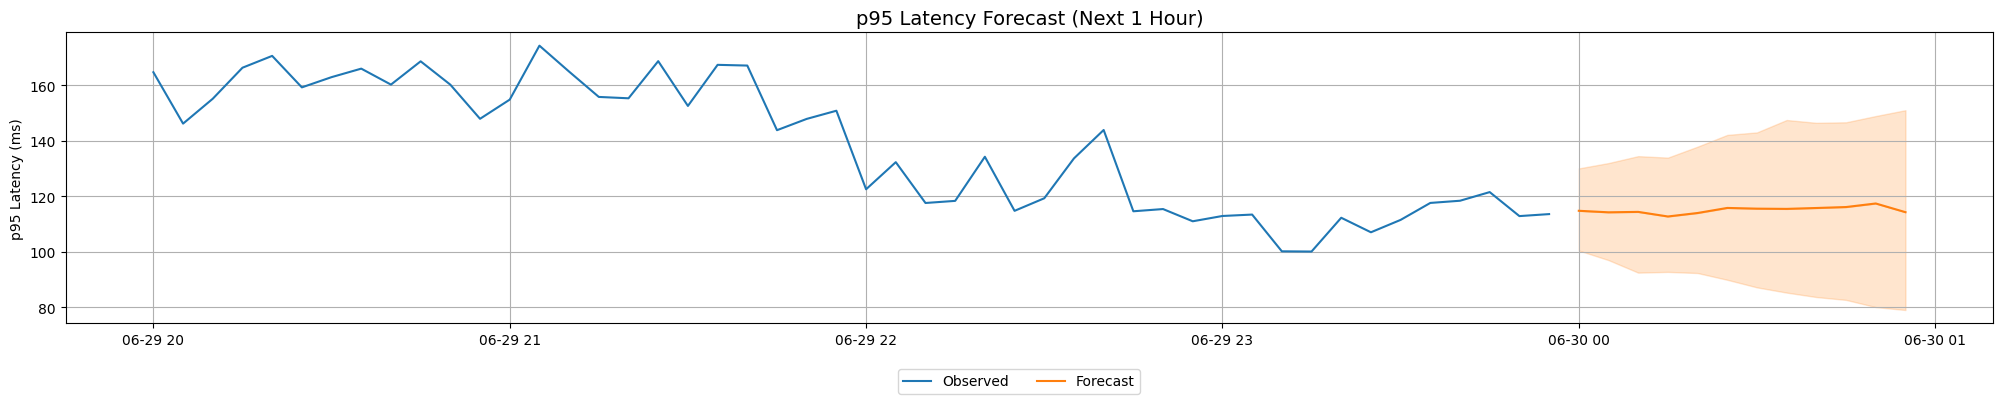

In [8]:
import matplotlib.pyplot as plt

# 1. Generate future predictions
predictions = predictor.predict(train_data)

# 2. Inspect the forecast table (mean, 10% lower bound, 90% upper bound)
print("=== Next 1-Hour Forecast ===")
print(predictions.head(12))

# 3. Plot the forecast alongside the last 4 hours of actual history
plt.figure(figsize=(12, 6))
predictor.plot(
    data=train_data,
    predictions=predictions,
    item_ids=["server_1"],
    max_history_length=48  # Show last 48 timesteps (4 hours)
)
plt.title("p95 Latency Forecast (Next 1 Hour)", fontsize=14)
plt.ylabel("p95 Latency (ms)")
plt.show()

In [9]:
predictor.leaderboard(train_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.098849,-0.098849,20.714377,27.035417,0.292771,8
1,Theta,-0.106912,-0.106912,0.545336,2.291440,0.032834,5
2,ETS,-0.114326,-0.114326,20.167953,24.742614,0.030337,4
3,Chronos2,-0.207143,-0.207143,0.482099,0.703987,18.487213,6
4,TemporalFusionTransformer,-0.208596,-0.208596,0.152660,0.077796,102.315658,7
5,DirectTabular,-0.225088,-0.225088,0.237595,0.223460,2.209192,3
6,SeasonalNaive,-0.243061,-0.243061,0.016593,1.929029,0.042032,1
7,RecursiveTabular,-0.251909,-0.251909,0.087980,0.085559,1.423674,2


In [10]:
from autogluon.timeseries import TimeSeriesPredictor

# 1. Define explicit models for XGBoost, Deep Learning, & LLMs
custom_hyperparameters = {
    # XGBoost, LightGBM, and CatBoost
    "RecursiveTabular": {
        "tabular_hyperparameters": {
            "XGB": {},   # XGBoost
            "CAT": {},   # CatBoost
            "GBDT": {},  # LightGBM
        }
    },
    "DirectTabular": {
        "tabular_hyperparameters": {
            "XGB": {},   # XGBoost
            "GBDT": {},  # LightGBM
        }
    },

    # Deep Learning (PyTorch)
    "TemporalFusionTransformer": {},
    "DeepAR": {},
    "PatchTST": {},
    "DLinear": {},

    # Time Series LLM / Foundation Model
    "Chronos": {
        "model_path": "amazon/chronos-bolt-small"
    },
}

# 2. Setup new predictor
predictor_advanced = TimeSeriesPredictor(
    prediction_length=12,
    target="p95_latency_ms",
    eval_metric="MASE",
    path="autogluon_latency_advanced"
)

# 3. Fit models (10 min budget)
predictor_advanced.fit(
    train_data,
    hyperparameters=custom_hyperparameters,
    time_limit=600
)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/kaggle/working/autogluon_latency_advanced'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat May 30 15:40:53 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.45/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.01 GB, Allocated: 0.12 GB, Total: 29.12 GB
GPU Count:          2
Memory Avail:       27.66 GB / 31.35 GB (88.2%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': {'model_path': 'amazon/chronos-bolt-small'},
                     'DLinear': {},
                     'DeepAR': {},
                     'DirectTabular': {'tabular_hyperparameters': {'GBDT': {},
                         

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

	-0.2131       = Validation score (-MASE)
	1.33    s     = Training runtime
	3.94    s     = Validation (prediction) runtime
Training timeseries model TemporalFusionTransformer. Training for up to 118.1s of the 590.3s of remaining time.
	-0.1336       = Validation score (-MASE)
	68.75   s     = Training runtime
	0.08    s     = Validation (prediction) runtime
Training timeseries model DeepAR. Training for up to 130.4s of the 521.4s of remaining time.
	-0.2011       = Validation score (-MASE)
	59.39   s     = Training runtime
	0.08    s     = Validation (prediction) runtime
Training timeseries model PatchTST. Training for up to 154.0s of the 461.9s of remaining time.
	-0.1420       = Validation score (-MASE)
	62.47   s     = Training runtime
	0.01    s     = Validation (prediction) runtime
Training timeseries model DLinear. Training for up to 199.7s of the 399.4s of remaining time.
	-0.1152       = Validation score (-MASE)
	54.26   s     = Training runtime
	0.01    s     = Validation (p

Model not specified in predict, will default to the model with the best validation score: DLinear


<Figure size 1200x600 with 0 Axes>

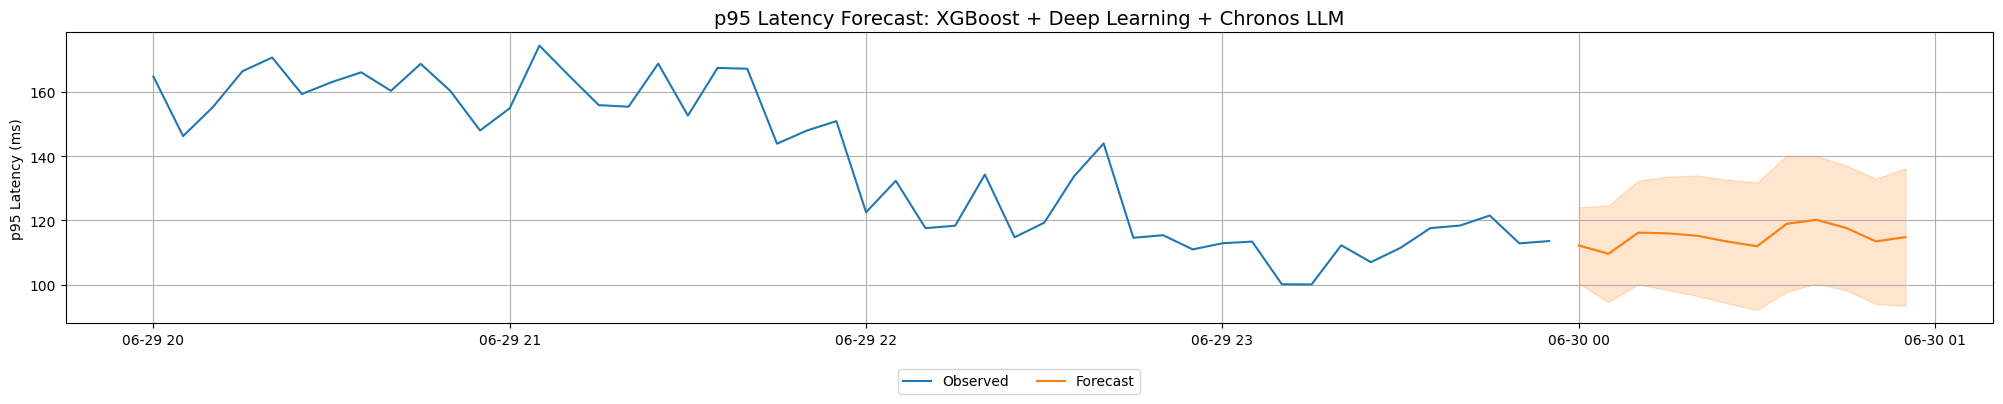

In [11]:
import matplotlib.pyplot as plt

# 1. Generate predictions with the advanced models
predictions_advanced = predictor_advanced.predict(train_data)

# 2. Plot history vs forecast
plt.figure(figsize=(12, 6))
predictor_advanced.plot(
    data=train_data,
    predictions=predictions_advanced,
    item_ids=["server_1"],
    max_history_length=48  # Show last 4 hours (48 * 5-min timesteps)
)
plt.title("p95 Latency Forecast: XGBoost + Deep Learning + Chronos LLM", fontsize=14)
plt.ylabel("p95 Latency (ms)")
plt.show()

In [12]:
# Display full leaderboard comparing XGBoost, Deep Learning, LLMs, and Ensembles
leaderboard = predictor_advanced.leaderboard(train_data)
leaderboard

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.115234,-0.115234,0.019779,0.011922,0.290020,8
1,DLinear,-0.115234,-0.115234,0.019331,0.011459,54.261713,7
2,TemporalFusionTransformer,-0.133551,-0.133551,0.146975,0.077472,68.749675,4
3,PatchTST,-0.141999,-0.141999,0.029641,0.013063,62.467604,6
4,DeepAR,-0.201095,-0.201135,0.087888,0.076438,59.391681,5
5,Chronos[amazon__chronos-bolt-small],-0.213064,-0.213064,0.292409,3.939041,1.327053,3
6,DirectTabular,-0.225088,-0.225088,0.224825,0.219596,2.475188,2
7,RecursiveTabular,-0.251909,-0.251909,0.084411,0.081216,1.625935,1


In [13]:
import shutil

# Zip the saved model folder (use 'autogluon-latency-model' or 'autogluon_latency_advanced')
shutil.make_archive('autogluon_model', 'zip', '/kaggle/working/autogluon-latency-model')
print("Model zipped successfully!")

Model zipped successfully!
